# 03 - Apriori Modeling (Association Rules Mining)

Mục tiêu:
- Khai thác luật kết hợp bằng Apriori
- Phát hiện tổ hợp đặc điểm nhân viên liên quan đến Attrition
- Lọc luật theo support / confidence / lift
- Phân tích và trực quan hóa luật
- Lưu luật đã lọc để sử dụng cho các bước tiếp theo

In [21]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Thiết lập project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.mining.association import (
    discretize_features,
    build_transactions,
    mine_association_rules,
    split_rules_by_attrition
)

In [22]:
df = pd.read_csv("../data/processed/hr_processed.csv")
print(df.shape)
df.head()

(1480, 53)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,SalarySlab_15k+,SalarySlab_5k-10k,SalarySlab_Upto 5k,OverTime_Yes,Attrition
0,18,230,3,3,3,54,3,1,3,1420,...,False,False,False,False,True,False,False,True,False,1
1,18,812,10,3,4,69,2,1,3,1200,...,False,False,True,False,True,False,False,True,False,0
2,18,1306,5,3,2,69,3,1,2,1878,...,False,False,True,False,True,False,False,True,True,1
3,18,287,5,2,2,73,3,1,4,1051,...,True,False,False,False,True,False,False,True,False,0
4,18,247,8,1,3,80,3,1,3,1904,...,False,False,False,False,True,False,False,True,False,1


# Association Rules - Apirori

In [23]:
# Tham số Apriori
# Tham số sinh luật
MIN_SUPPORT = 0.02

# Tham số lọc luật
FILTER_MIN_SUPPORT = 0.05
FILTER_MIN_CONF = 0.6
FILTER_MIN_LIFT = 1.2
FILTER_MAX_ANTECEDENTS = 3
FILTER_MAX_CONSEQUENTS = 1

print("Apriori parameters:")
print(f"- Min support (generate): {MIN_SUPPORT}")
print(f"- Min support (filter)  : {FILTER_MIN_SUPPORT}")
print(f"- Min confidence        : {FILTER_MIN_CONF}")
print(f"- Min lift              : {FILTER_MIN_LIFT}")

Apriori parameters:
- Min support (generate): 0.02
- Min support (filter)  : 0.05
- Min confidence        : 0.6
- Min lift              : 1.2


In [24]:
df_disc = discretize_features(df)
transactions = build_transactions(df_disc)

print(f"Số transaction                 : {transactions.shape[0]:,}")
print(f"Số item trung bình / transaction: {transactions.sum(axis=1).mean():.2f}")

transactions.head()

Số transaction                 : 1,480
Số item trung bình / transaction: 7.00


,"Age_bin_(18, 30]","Age_bin_(30, 40]","Age_bin_(40, 50]","Age_bin_(50, 60]",Age_bin_nan,"MonthlyIncome_bin_(0, 3000]","MonthlyIncome_bin_(10000, 20000]","MonthlyIncome_bin_(3000, 6000]","MonthlyIncome_bin_(6000, 10000]","TotalWorkingYears_bin_(0, 5]",...,YearsAtCompany_bin_nan,OverTime_Yes_False,OverTime_Yes_True,JobLevel_1,JobLevel_2,JobLevel_3,JobLevel_4,JobLevel_5,AttritionLabel_Leave,AttritionLabel_Stay
0,False,False,False,False,True,True,False,False,False,False,...,True,True,False,True,False,False,False,False,True,False
1,False,False,False,False,True,True,False,False,False,False,...,True,True,False,True,False,False,False,False,False,True
2,False,False,False,False,True,True,False,False,False,False,...,True,False,True,True,False,False,False,False,True,False
3,False,False,False,False,True,True,False,False,False,False,...,True,True,False,True,False,False,False,False,False,True
4,False,False,False,False,True,True,False,False,False,False,...,True,True,False,True,False,False,False,False,True,False


In [25]:
# Khai phá luật kết hợp (Apriori)
rules_ap = mine_association_rules(
    transactions,
    min_support=MIN_SUPPORT,
)

print(f"Tổng số luật sinh ra ban đầu: {rules_ap.shape[0]:,}")

rules_ap.head()

Tổng số luật sinh ra ban đầu: 21,796


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"(MonthlyIncome_bin_(0, 3000])","(Age_bin_(18, 30])",0.268243,0.257432,0.122973,0.458438,1.780810,1.0,0.053918,1.371160,0.599185,0.305369,0.270690,0.468064
1,"(Age_bin_(18, 30])","(MonthlyIncome_bin_(0, 3000])",0.257432,0.268243,0.122973,0.477690,1.780810,1.0,0.053918,1.401002,0.590462,0.305369,0.286225,0.468064
2,"(Age_bin_(18, 30])","(MonthlyIncome_bin_(3000, 6000])",0.257432,0.352703,0.095270,0.370079,1.049265,1.0,0.004473,1.027584,0.063230,0.185039,0.026844,0.320097
3,"(MonthlyIncome_bin_(3000, 6000])","(Age_bin_(18, 30])",0.352703,0.257432,0.095270,0.270115,1.049265,1.0,0.004473,1.017376,0.072536,0.185039,0.017079,0.320097
4,"(MonthlyIncome_bin_(6000, 10000])","(Age_bin_(18, 30])",0.187838,0.257432,0.035811,0.190647,0.740573,1.0,-0.012545,0.917483,-0.301347,0.087459,-0.089938,0.164878


In [26]:
# ===== LỌC, SẮP XẾP & CHỌN TOP-K LUẬT (KHÔNG ÉP CONSEQUENT) =====

n_rules_raw = rules_ap.shape[0]
print("Tổng số luật ban đầu:", n_rules_raw)

rules_filtered = rules_ap[
    (rules_ap["support"] >= FILTER_MIN_SUPPORT) &
    (rules_ap["confidence"] >= FILTER_MIN_CONF) &
    (rules_ap["lift"] >= FILTER_MIN_LIFT) &
    (rules_ap["antecedents"].apply(len) <= FILTER_MAX_ANTECEDENTS) &
    (rules_ap["consequents"].apply(len) <= FILTER_MAX_CONSEQUENTS)
].copy()

print("Sau lọc ngưỡng cơ bản:", rules_filtered.shape[0])

# ===== LOẠI LUẬT CHỨA NaN =====
def has_nan_item(items):
    return any("nan" in str(item).lower() for item in items)

rules_filtered = rules_filtered[
    ~rules_filtered["antecedents"].apply(has_nan_item) &
    ~rules_filtered["consequents"].apply(has_nan_item)
]

print("Sau loại luật chứa NaN:", rules_filtered.shape[0])

# ===== LOẠI LUẬT HIỂN NHIÊN =====
def is_trivial_rule(row):
    a = " ".join(row["antecedents"])
    c = " ".join(row["consequents"])
    return (
        ("JobLevel" in a and "MonthlyIncome" in c) or
        ("MonthlyIncome" in a and "JobLevel" in c)
    )

rules_filtered = rules_filtered[
    ~rules_filtered.apply(is_trivial_rule, axis=1)
]

print("Sau loại luật hiển nhiên:", rules_filtered.shape[0])

# ===== SORT & TOP-K =====
rules_filtered = rules_filtered.sort_values(
    by=["lift", "confidence", "support"],
    ascending=[False, False, False]
)

TOP_K = 100
rules_topk = rules_filtered.head(TOP_K)

print(f"Số luật cuối cùng (Top-{TOP_K}): {rules_topk.shape[0]}")

cols_preview = ["antecedents", "consequents", "support", "confidence", "lift"]
rules_topk[cols_preview].head(10)

Tổng số luật ban đầu: 21796
Sau lọc ngưỡng cơ bản: 250
Sau loại luật chứa NaN: 250
Sau loại luật hiển nhiên: 139
Số luật cuối cùng (Top-100): 100


,antecedents,consequents,support,confidence,lift
274,(JobLevel_4),"(TotalWorkingYears_bin_(20, 40])",0.067568,0.934579,6.649892
2085,"(JobLevel_4, MonthlyIncome_bin_(10000, 20000])","(TotalWorkingYears_bin_(20, 40])",0.067568,0.934579,6.649892
3020,"(AttritionLabel_Stay, JobLevel_4)","(TotalWorkingYears_bin_(20, 40])",0.064189,0.931373,6.627074
8543,"(AttritionLabel_Stay, JobLevel_4, MonthlyIncom...","(TotalWorkingYears_bin_(20, 40])",0.064189,0.931373,6.627074
6849,"(MonthlyIncome_bin_(10000, 20000], OverTime_Ye...","(TotalWorkingYears_bin_(20, 40])",0.050000,0.880952,6.268315
6905,"(Age_bin_(40, 50], AttritionLabel_Stay, Monthl...","(TotalWorkingYears_bin_(20, 40])",0.066892,0.860870,6.125418
1365,"(Age_bin_(40, 50], MonthlyIncome_bin_(10000, 2...","(TotalWorkingYears_bin_(20, 40])",0.070946,0.846774,6.025124
8431,"(YearsAtCompany_bin_(10, 40], AttritionLabel_S...","(TotalWorkingYears_bin_(20, 40])",0.064865,0.768000,5.464615
2055,"(YearsAtCompany_bin_(10, 40], MonthlyIncome_bi...","(TotalWorkingYears_bin_(20, 40])",0.072297,0.764286,5.438187
8375,"(YearsAtCompany_bin_(10, 40], OverTime_Yes_Fal...","(TotalWorkingYears_bin_(20, 40])",0.050676,0.750000,5.336538


In [27]:
# =========================================================
# PHÂN TÍCH LUẬT THEO TRẠNG THÁI (ATTRITION)
# =========================================================

leave_rules_all, stay_rules_all = split_rules_by_attrition(rules_ap)

print("Tổng luật liên quan đến nghỉ việc (chưa lọc):", leave_rules_all.shape[0])
print("Tổng luật liên quan đến ở lại    (chưa lọc):", stay_rules_all.shape[0])

leave_rules = leave_rules_all[
    (leave_rules_all["support"] >= 0.01) &
    (leave_rules_all["confidence"] >= 0.3) &
    (leave_rules_all["lift"] >= 1.2)
]

stay_rules = stay_rules_all[
    (stay_rules_all["support"] >= 0.01) &
    (stay_rules_all["confidence"] >= 0.3) &
    (stay_rules_all["lift"] >= 1.2)
]

print("\nSau lọc luật Attrition:")
print("Số luật liên quan đến nghỉ việc:", leave_rules.shape[0])
print("Số luật liên quan đến ở lại    :", stay_rules.shape[0])

Tổng luật liên quan đến nghỉ việc (chưa lọc): 1048
Tổng luật liên quan đến ở lại    (chưa lọc): 13366

Sau lọc luật Attrition:
Số luật liên quan đến nghỉ việc: 460
Số luật liên quan đến ở lại    : 4349


In [28]:
# =========================================================
# SO SÁNH CÁC TRƯỜNG HỢP TOP_K
# =========================================================

TOP_K_LIST = [10, 20, 50, 100, 200, 300, 400]
rows = []

for k in TOP_K_LIST:
    top_leave = leave_rules.sort_values("lift", ascending=False).head(k)
    top_stay  = stay_rules.sort_values("lift", ascending=False).head(k)

    rows.append({
        "TOP_K": k,
        "Leave_Count": top_leave.shape[0],
        "Stay_Count": top_stay.shape[0],
        "Leave_Lift_Mean": top_leave["lift"].mean(),
        "Stay_Lift_Mean": top_stay["lift"].mean(),
        "Leave_Conf_Mean": top_leave["confidence"].mean(),
        "Stay_Conf_Mean": top_stay["confidence"].mean(),
    })

df_topk_compare = pd.DataFrame(rows)
display(df_topk_compare)

,TOP_K,Leave_Count,Stay_Count,Leave_Lift_Mean,Stay_Lift_Mean,Leave_Conf_Mean,Stay_Conf_Mean
0,10,10,10,7.832174,9.325970,0.448918,0.475661
1,20,20,20,7.566685,8.808629,0.449726,0.510582
2,50,50,50,6.734540,8.243974,0.515729,0.533126
3,100,100,100,6.003570,7.899958,0.495723,0.570628
4,200,200,200,5.129772,7.524006,0.517431,0.612148
5,300,300,300,4.461643,7.259399,0.557184,0.617973
6,400,400,400,3.941106,7.014862,0.574191,0.588953


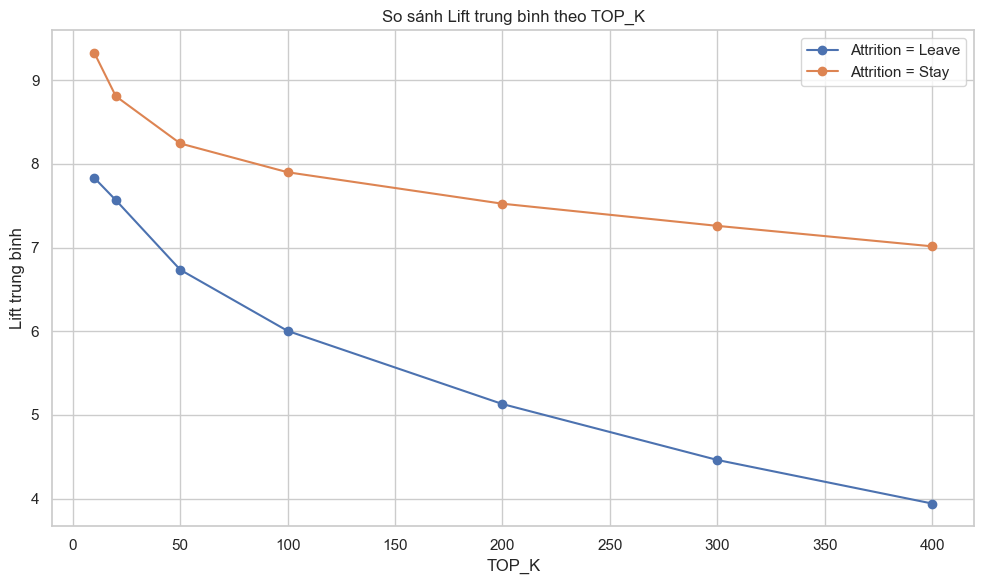

In [29]:
# So sánh Lift trung bình theo TOP_K
plt.figure(figsize=(10, 6))

plt.plot(
    df_topk_compare["TOP_K"],
    df_topk_compare["Leave_Lift_Mean"],
    marker="o",
    label="Attrition = Leave"
)

plt.plot(
    df_topk_compare["TOP_K"],
    df_topk_compare["Stay_Lift_Mean"],
    marker="o",
    label="Attrition = Stay"
)

plt.xlabel("TOP_K")
plt.ylabel("Lift trung bình")
plt.title("So sánh Lift trung bình theo TOP_K")
plt.legend()
plt.tight_layout()
plt.show()

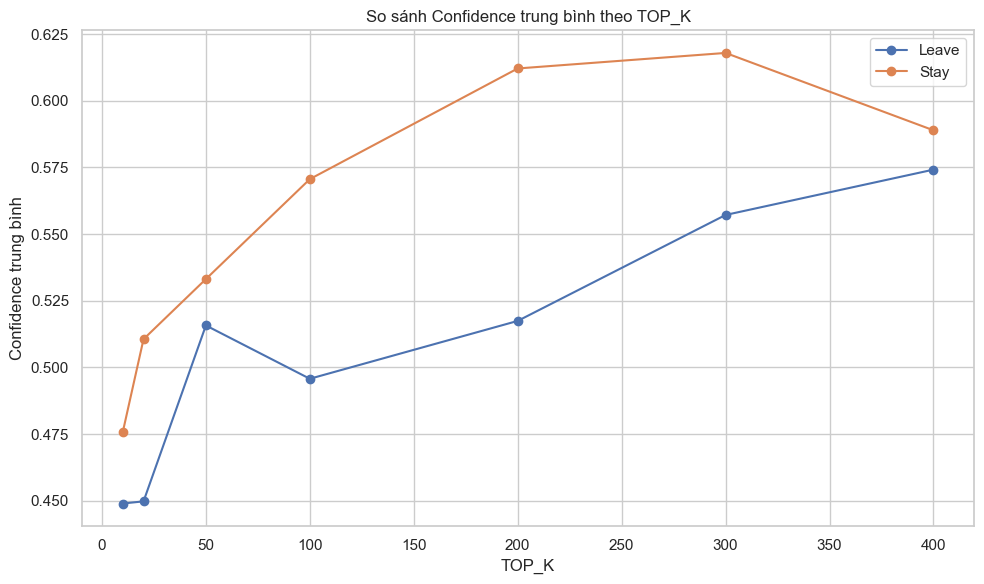

In [30]:
# Confidence trung bình theo TOP_K
plt.figure(figsize=(10, 6))

plt.plot(
    df_topk_compare["TOP_K"],
    df_topk_compare["Leave_Conf_Mean"],
    marker="o",
    label="Leave"
)

plt.plot(
    df_topk_compare["TOP_K"],
    df_topk_compare["Stay_Conf_Mean"],
    marker="o",
    label="Stay"
)

plt.xlabel("TOP_K")
plt.ylabel("Confidence trung bình")
plt.title("So sánh Confidence trung bình theo TOP_K")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# =========================================================
# CHỐT TOP_K CUỐI CÙNG = 100
# =========================================================

FINAL_TOP_K = 100
print("=== 100 luật tiêu biểu (theo lift) sau khi lọc ===")
final_leave_rules = (
    leave_rules
    .sort_values("lift", ascending=False)
    .head(FINAL_TOP_K)
    .copy()
)

final_stay_rules = (
    stay_rules
    .sort_values("lift", ascending=False)
    .head(FINAL_TOP_K)
    .copy()
)

# =========================================================
# TẠO TÊN LUẬT ĐỂ DÙNG CHO TRỰC QUAN
# =========================================================

def format_rule(row):
    return f"{', '.join(row['antecedents'])} → {', '.join(row['consequents'])}"

final_leave_rules["rule_name"] = final_leave_rules.apply(format_rule, axis=1)
final_stay_rules["rule_name"]  = final_stay_rules.apply(format_rule, axis=1)

# =========================================================
# HIỂN THỊ BẢNG LUẬT (CÓ TÊN LUẬT)
# =========================================================

display(
    final_leave_rules[
        ["rule_name", "support", "confidence", "lift"]
    ]
)

display(
    final_stay_rules[
        ["rule_name", "support", "confidence", "lift"]
    ]
)

=== 100 luật tiêu biểu (theo lift) sau khi lọc ===


,rule_name,support,confidence,lift
18728,"MonthlyIncome_bin_(0, 3000], AttritionLabel_Le...",0.025000,0.552239,8.339933
18717,"YearsAtCompany_bin_(0, 2], JobLevel_1, Age_bin...",0.025000,0.377551,8.339933
18718,"MonthlyIncome_bin_(0, 3000], YearsAtCompany_bi...",0.025000,0.435294,8.052941
18727,"AttritionLabel_Leave, JobLevel_1, TotalWorking...",0.025000,0.462500,8.052941
11051,"MonthlyIncome_bin_(0, 3000], AttritionLabel_Le...",0.025000,0.552239,7.638443
...,...,...,...,...
11045,"AttritionLabel_Leave, YearsAtCompany_bin_(0, 2...",0.025000,0.627119,5.099646
11056,"YearsAtCompany_bin_(0, 2], AttritionLabel_Leav...",0.025000,0.430233,5.093953
4402,"TotalWorkingYears_bin_(0, 5], AttritionLabel_L...",0.020946,0.360465,5.080842
12128,"YearsAtCompany_bin_(0, 2], JobLevel_1, Attriti...",0.027703,0.621212,5.024011


,rule_name,support,confidence,lift
19800,"YearsAtCompany_bin_(10, 40], JobLevel_2 → Attr...",0.023649,0.500000,10.571429
19753,"AttritionLabel_Stay, Age_bin_(30, 40], TotalWo...",0.023649,0.500000,10.571429
19767,"Age_bin_(30, 40], TotalWorkingYears_bin_(10, 2...",0.023649,0.454545,10.040706
19786,"YearsAtCompany_bin_(10, 40], AttritionLabel_St...",0.023649,0.522388,10.040706
20809,"YearsAtCompany_bin_(10, 40], AttritionLabel_St...",0.020270,0.312500,8.894231
...,...,...,...,...
17173,"TotalWorkingYears_bin_(10, 20], MonthlyIncome_...",0.032432,0.335664,7.414675
17172,"YearsAtCompany_bin_(10, 40], AttritionLabel_St...",0.032432,0.716418,7.414675
13087,"AttritionLabel_Stay, Age_bin_(30, 40], JobLeve...",0.022973,0.350515,7.410898
13098,"TotalWorkingYears_bin_(10, 20], MonthlyIncome_...",0.022973,0.485714,7.410898


# Trực quan hoá luật kết hợp

#### TOP LUẬT THEO LIFT (TOP_K = 100)

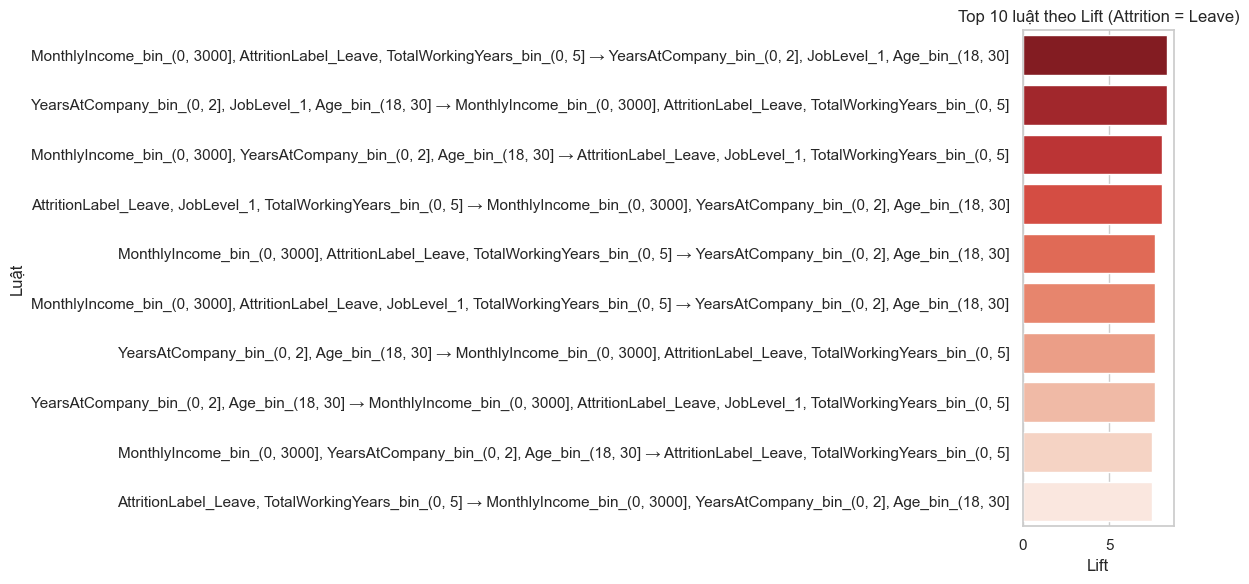

In [32]:
# Top luật theo Lift – Leave
top_lift_leave = final_leave_rules.sort_values("lift", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_lift_leave,
    x="lift",
    y="rule_name",
    palette="Reds_r"
)

plt.xlabel("Lift")
plt.ylabel("Luật")
plt.title("Top 10 luật theo Lift (Attrition = Leave)")
plt.tight_layout()
plt.show()

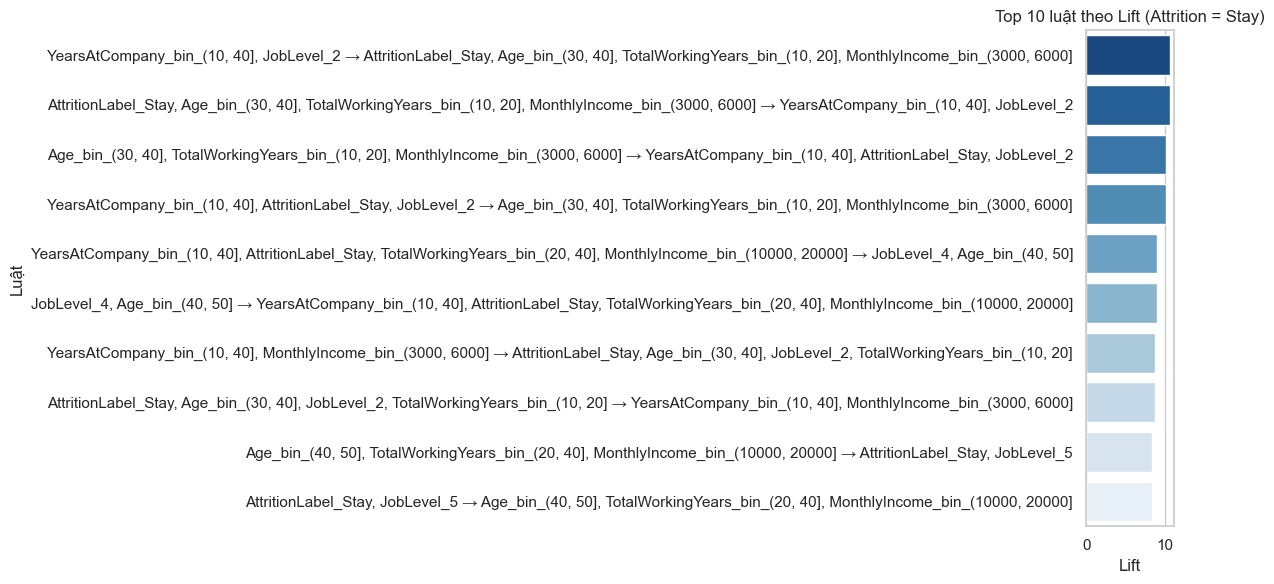

In [33]:
# Top luật theo Lift – Stay
top_lift_stay = final_stay_rules.sort_values("lift", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_lift_stay,
    x="lift",
    y="rule_name",
    palette="Blues_r"
)

plt.xlabel("Lift")
plt.ylabel("Luật")
plt.title("Top 10 luật theo Lift (Attrition = Stay)")
plt.tight_layout()
plt.show()

#### TOP LUẬT THEO CONFIDENCE (TOP_K = 100)

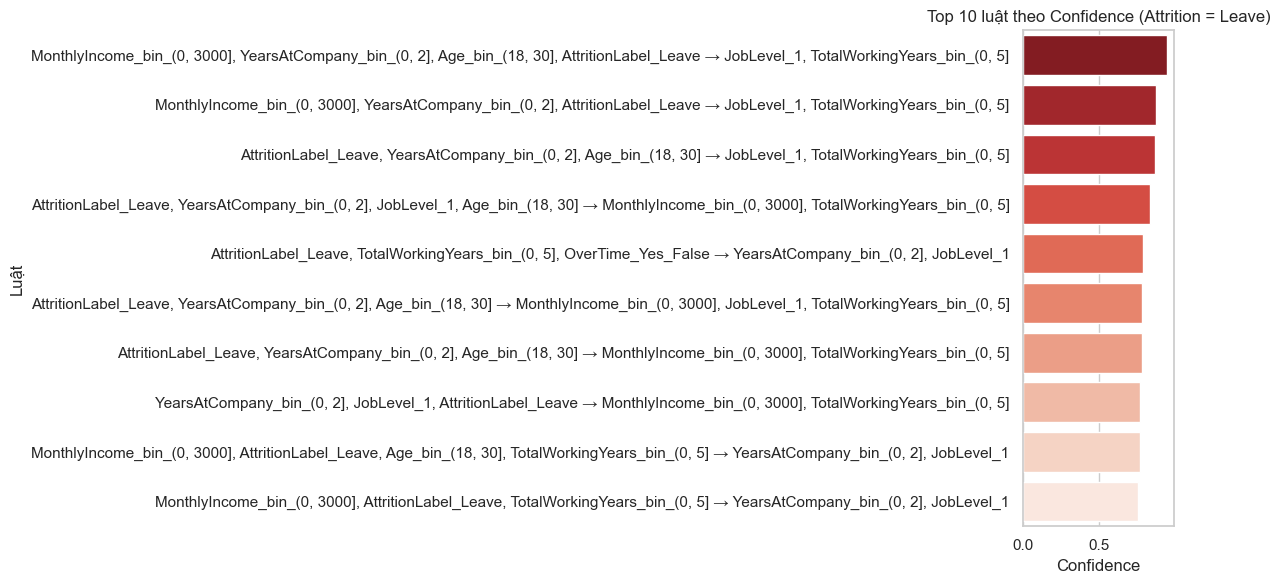

In [34]:
# Top luật theo Confidence – Leave
top_conf_leave = final_leave_rules.sort_values("confidence", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_conf_leave,
    x="confidence",
    y="rule_name",
    palette="Reds_r"
)

plt.xlabel("Confidence")
plt.ylabel("Luật")
plt.title("Top 10 luật theo Confidence (Attrition = Leave)")
plt.tight_layout()
plt.show()

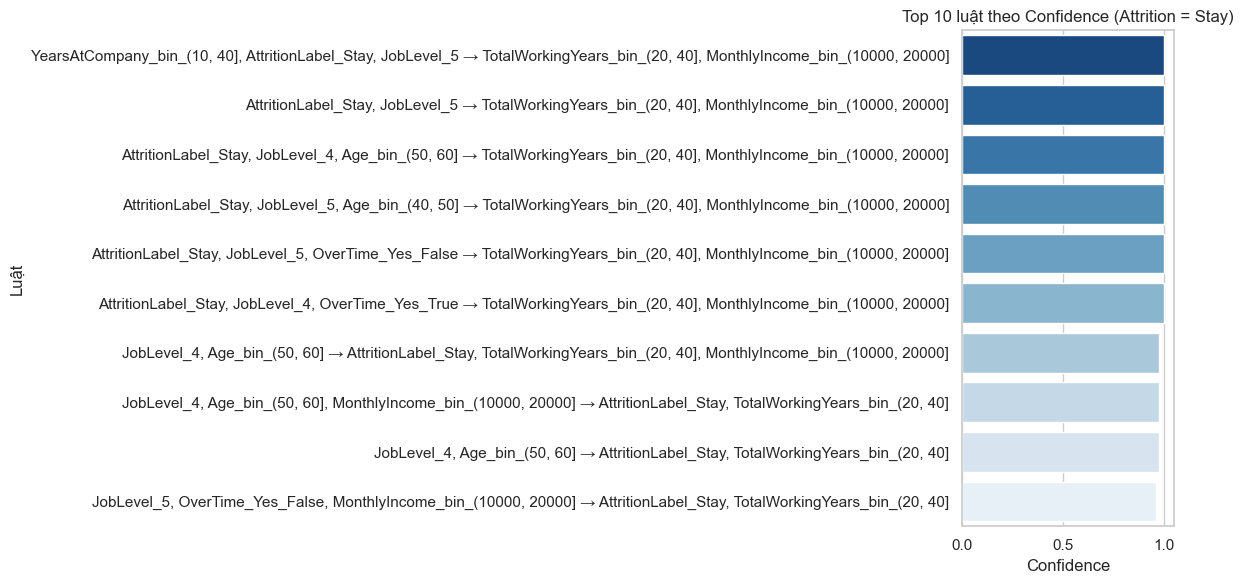

In [35]:
# Top luật theo Confidence – Stay
top_conf_stay = final_stay_rules.sort_values("confidence", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_conf_stay,
    x="confidence",
    y="rule_name",
    palette="Blues_r"
)

plt.xlabel("Confidence")
plt.ylabel("Luật")
plt.title("Top 10 luật theo Confidence (Attrition = Stay)")
plt.tight_layout()
plt.show()

#### SUPPORT VS CONFIDENCE (SCATTER PLOT)

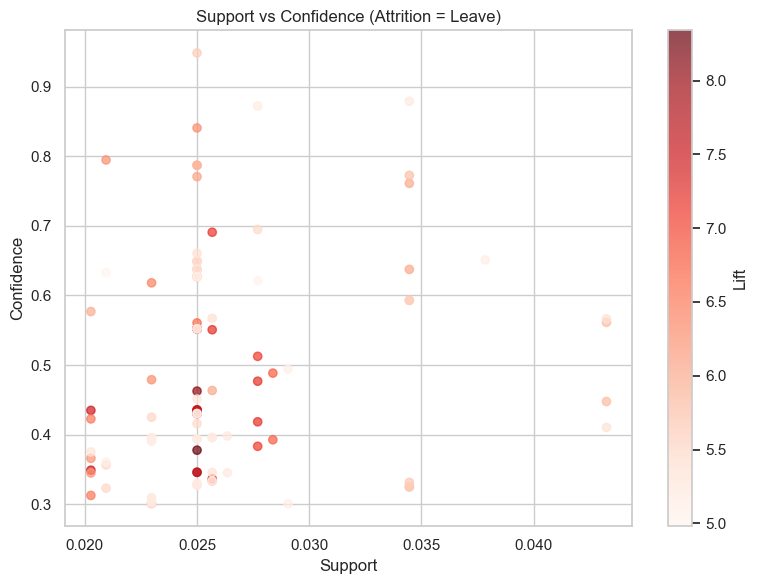

In [36]:
# Scatter Support – Confidence – Leave
plt.figure(figsize=(8, 6))
plt.scatter(
    final_leave_rules["support"],
    final_leave_rules["confidence"],
    c=final_leave_rules["lift"],
    cmap="Reds",
    alpha=0.7
)

plt.colorbar(label="Lift")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence (Attrition = Leave)")
plt.tight_layout()
plt.show()

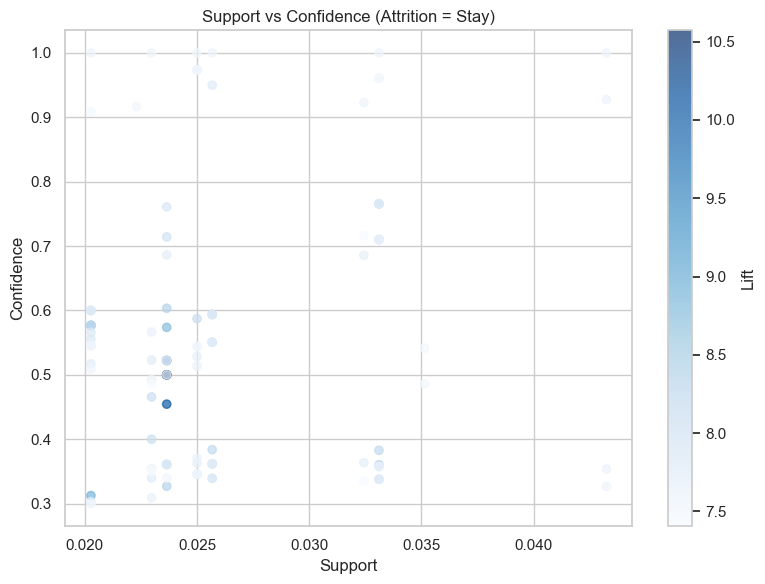

In [37]:
# Scatter Support – Confidence – Stay
plt.figure(figsize=(8, 6))
plt.scatter(
    final_stay_rules["support"],
    final_stay_rules["confidence"],
    c=final_stay_rules["lift"],
    cmap="Blues",
    alpha=0.7
)

plt.colorbar(label="Lift")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence (Attrition = Stay)")
plt.tight_layout()
plt.show()

In [38]:
# So sánh Lift & Confidence trung bình (Leave vs Stay)
summary_topk = pd.DataFrame({
    "Group": ["Leave", "Stay"],
    "Mean_Lift": [
        final_leave_rules["lift"].mean(),
        final_stay_rules["lift"].mean()
    ],
    "Mean_Confidence": [
        final_leave_rules["confidence"].mean(),
        final_stay_rules["confidence"].mean()
    ]
})

summary_topk

,Group,Mean_Lift,Mean_Confidence
0,Leave,6.003570,0.495723
1,Stay,7.899958,0.570628


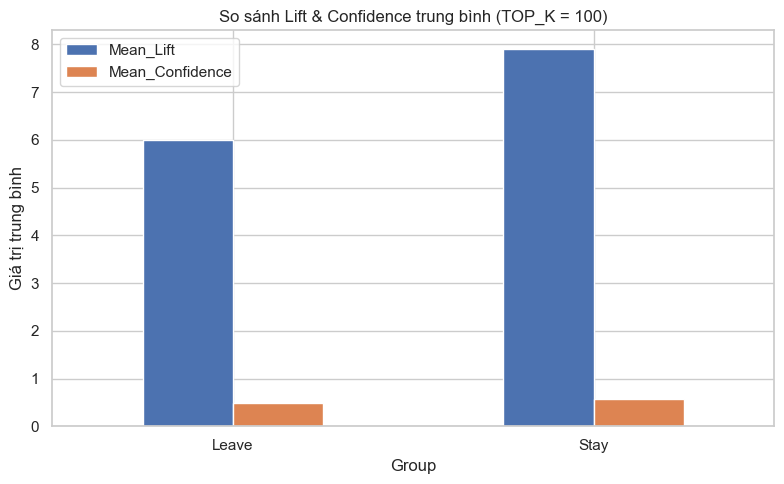

In [39]:
summary_topk.set_index("Group")[["Mean_Lift", "Mean_Confidence"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("So sánh Lift & Confidence trung bình (TOP_K = 100)")
plt.ylabel("Giá trị trung bình")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
# =========================================================
# LƯU LUẬT APRIORI
# =========================================================

OUTPUT_DIR = "../data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Toàn bộ luật Apriori (chưa lọc)
rules_ap.to_csv(
    f"{OUTPUT_DIR}/rules_apriori_all.csv",
    index=False
)

# 2. Luật đã lọc theo support / confidence / lift
rules_filtered.to_csv(
    f"{OUTPUT_DIR}/rules_apriori_filtered.csv",
    index=False
)

# 3. Top-K luật (đầu vào cho bước tiếp theo)
rules_topk.to_csv(
    f"{OUTPUT_DIR}/rules_apriori_topk.csv",
    index=False
)

# 4. Luật liên quan đến Attrition = Leave
final_leave_rules.to_csv(
    f"{OUTPUT_DIR}/rules_apriori_leave_top100.csv",
    index=False
)

# 5. Luật liên quan đến Attrition = Stay
final_stay_rules.to_csv(
    f"{OUTPUT_DIR}/rules_apriori_stay_top100.csv",
    index=False
)

print("✅ Đã lưu đầy đủ luật Apriori (TOP_K = 100):")
print("- rules_apriori_all.csv")
print("- rules_apriori_filtered.csv")
print("- rules_apriori_topk.csv")
print("- rules_apriori_leave_top100.csv")
print("- rules_apriori_stay_top100.csv")

✅ Đã lưu đầy đủ luật Apriori (TOP_K = 100):
- rules_apriori_all.csv
- rules_apriori_filtered.csv
- rules_apriori_topk.csv
- rules_apriori_leave_top100.csv
- rules_apriori_stay_top100.csv
